In [1]:
import os
import random

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

2026-08-05 15:24:33.888662: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed:", SEED)

Seed: 42


In [3]:
IMG_SIZE = (224,224)

BATCH_SIZE = 32

EPOCHS = 20

LEARNING_RATE = 0.001

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    "valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2567 files belonging to 20 classes.
Found 100 files belonging to 20 classes.
Found 100 files belonging to 20 classes.


In [5]:
class_names = train_ds.class_names

print("Classes:")

for i, c in enumerate(class_names):
    print(i, c)

Classes:
0 ARCIGERA FLOWER MOTH
1 ATLAS MOTH
2 BANDED TIGER MOTH
3 BIRD CHERRY ERMINE MOTH
4 CINNABAR MOTH
5 CLEARWING MOTH
6 COMET MOTH
7 EMPEROR GUM MOTH
8 GARDEN TIGER MOTH
9 GIANT LEOPARD MOTH
10 HERCULES MOTH
11 HUMMING BIRD HAWK MOTH
12 IO MOTH
13 LUNA MOTH
14 MADAGASCAN SUNSET MOTH
15 OLEANDER HAWK MOTH
16 POLYPHEMUS MOTH
17 ROSY MAPLE MOTH
18 SIXSPOT BURNET MOTH
19 WHITE LINED SPHINX MOTH


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

valid_ds = valid_ds.prefetch(
    buffer_size=AUTOTUNE
)

test_ds = test_ds.prefetch(
    buffer_size=AUTOTUNE
)

### Data Augmentation

In [7]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.GaussianNoise(0.05)

])

### Build ResNet50

In [8]:
base_model = ResNet50(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

base_model.trainable = False

In [9]:
inputs = tf.keras.Input(
    shape=(224,224,3)
)

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(
    20,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

In [10]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 20)        │     40,980 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,628,692 (90.14 MB)

 Trainable params: 40,980 (160.08 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [12]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

In [13]:
history = model.fit(

    train_ds,

    validation_data=valid_ds,

    epochs=EPOCHS,

    callbacks=[early_stop]

)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.5699 - loss: 1.5304 - val_accuracy: 0.9100 - val_loss: 0.3856
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.8644 - loss: 0.4517 - val_accuracy: 0.9400 - val_loss: 0.2950
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.8964 - loss: 0.3388 - val_accuracy: 0.9500 - val_loss: 0.3015
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.9194 - loss: 0.2593 - val_accuracy: 0.9500 - val_loss: 0.2347
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.9307 - loss: 0.2339 - val_accuracy: 0.9500 - val_loss: 0.2705
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.9392 - loss: 0.2013 - val_accuracy: 0.9400 - val_loss: 0.2804
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.9392 - loss: 0.1986 - val_accuracy: 0.9400 - val_loss: 0.2917
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.9536 - loss: 0.1488 - val_accuracy: 0.9400 - v

### Accuracy Curve

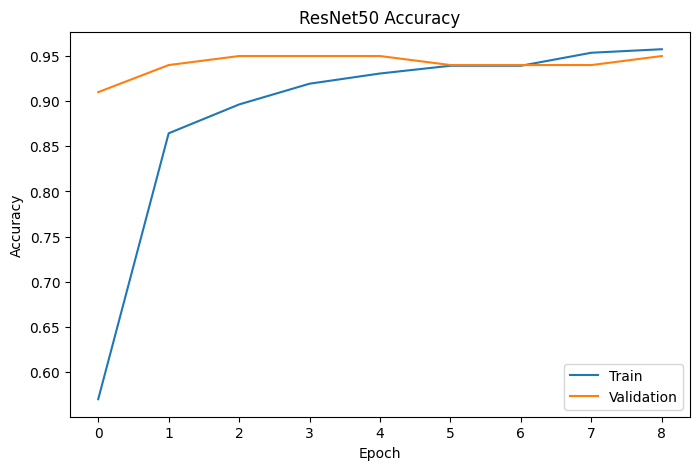

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Train"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("ResNet50 Accuracy")

plt.legend()

plt.show()

### Loss Curve

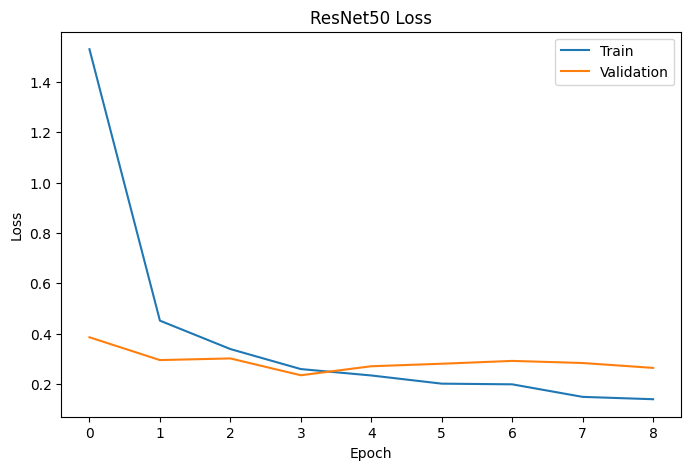

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Train"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("ResNet50 Loss")

plt.legend()

plt.show()

### Evaluate Model

In [16]:
test_loss, test_acc = model.evaluate(
    test_ds
)

print(
    "Test Accuracy:",
    test_acc
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 926ms/step - accuracy: 0.9600 - loss: 0.0822
Test Accuracy: 0.9599999785423279


### Predictions

In [17]:
y_true = []

for images, labels in test_ds:

    y_true.extend(
        labels.numpy()
    )

2026-08-05 15:57:04.905499: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [18]:
predictions = model.predict(
    test_ds
)

y_pred = np.argmax(
    predictions,
    axis=1
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step


In [19]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(y_true.shape)
print(y_pred.shape)

prediction_df = pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred
})

prediction_df.to_csv(
    "ResNet50_predictions.csv",
    index=False
)

print("ResNet50_predictions.csv saved.")

(100,)
(100,)
ResNet50_predictions.csv saved.


### Confusion Matrix

In [20]:
cm = confusion_matrix(
    y_true,
    y_pred
)

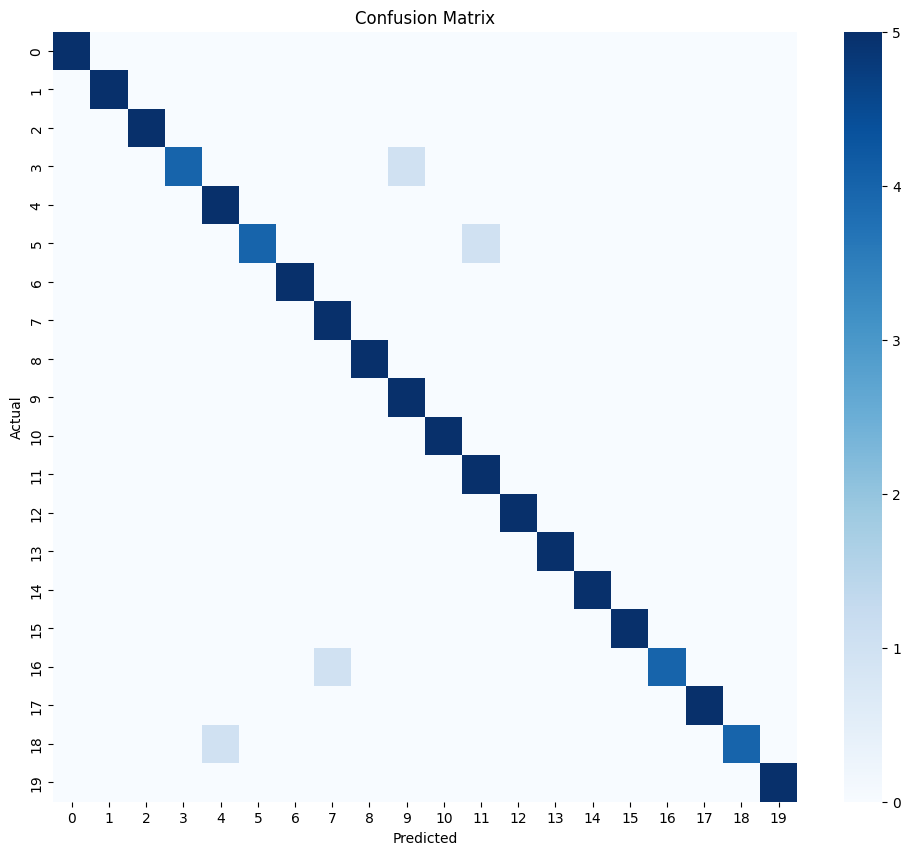

In [21]:
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

### Classification Report

In [22]:
print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names

    )
)

                         precision    recall  f1-score   support

   ARCIGERA FLOWER MOTH       1.00      1.00      1.00         5
             ATLAS MOTH       1.00      1.00      1.00         5
      BANDED TIGER MOTH       1.00      1.00      1.00         5
BIRD CHERRY ERMINE MOTH       1.00      0.80      0.89         5
          CINNABAR MOTH       0.83      1.00      0.91         5
         CLEARWING MOTH       1.00      0.80      0.89         5
             COMET MOTH       1.00      1.00      1.00         5
       EMPEROR GUM MOTH       0.83      1.00      0.91         5
      GARDEN TIGER MOTH       1.00      1.00      1.00         5
     GIANT LEOPARD MOTH       0.83      1.00      0.91         5
          HERCULES MOTH       1.00      1.00      1.00         5
 HUMMING BIRD HAWK MOTH       0.83      1.00      0.91         5
                IO MOTH       1.00      1.00      1.00         5
              LUNA MOTH       1.00      1.00      1.00         5
 MADAGASCAN SUNSET MOTH 

In [23]:
results = {
    "accuracy": test_acc,
    "loss": test_loss
}

print(results)

{'accuracy': 0.9599999785423279, 'loss': 0.08220188319683075}


In [24]:
model.save(
    "ResNet50.keras"
)